<a href="https://colab.research.google.com/github/Muhammad-AHMAD07/ML_Lab/blob/main/Lab10_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab Manual 10: Support Vector Machines (SVM)

## Task 1: Load Dataset

In [2]:
import pandas as pd
from sklearn import datasets # Kept for potential future use or consistency, but not used for this dataset

# Load the heart disease dataset
heart_df = pd.read_csv('/content/heart_disease_uci.csv')

# Explicitly define X and y using 'num' as the target column, as identified in Task 2
if 'num' in heart_df.columns:
    X = heart_df.drop('num', axis=1)
    y = heart_df['num']
else:
    # Fallback or error if 'num' is not found
    print("Error: 'num' target column not found in the dataset.")
    # Raise an error to prevent further execution with an incorrect target
    raise ValueError("'num' column not found, cannot proceed without a target.")

# Display basic information about the dataset
print("Heart Disease Dataset loaded successfully.")
print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print("\nFirst 5 rows of the dataset:")
display(heart_df.head())

# Assign heart_df to df to maintain compatibility with later cells that might use 'df'
df = heart_df

Heart Disease Dataset loaded successfully.
Features (X) shape: (920, 15)
Target (y) shape: (920,)

First 5 rows of the dataset:


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


## Task 2: Data Preprocessing (Feature Scaling and Splitting Data)

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np
import pandas as pd

# --- Data Cleaning and Preprocessing for heart_disease_uci.csv ---
# Make a copy to avoid modifying the original heart_df directly
processed_df = heart_df.copy()

# Drop 'id' and 'dataset' columns as they are not features
if 'id' in processed_df.columns:
    processed_df = processed_df.drop(columns=['id'])
if 'dataset' in processed_df.columns:
    processed_df = processed_df.drop(columns=['dataset'])

# Replace '?' with NaN in all columns where it might appear
processed_df = processed_df.replace('?', np.nan)

# Convert relevant columns to numeric, coercing errors will turn invalid parsing into NaN
# These columns are known to have '?' values that prevent them from being numeric by default
for col in ['ca', 'thal']:
    if col in processed_df.columns:
        processed_df[col] = pd.to_numeric(processed_df[col], errors='coerce')

# Separate features (X) and target (y)
X = processed_df.drop('num', axis=1) # 'num' is the target column in this dataset
y = processed_df['num']

# Identify categorical and numerical columns dynamically
categorical_cols = X.select_dtypes(include=['object', 'category']).columns
numerical_cols = X.select_dtypes(include=np.number).columns

# Create preprocessing pipelines
# Numerical transformer: impute missing values with the mean
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean'))
])

# Categorical transformer: impute missing values with the most frequent value, then one-hot encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Create a preprocessor using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ],
    remainder='passthrough' # Keep any other columns not specified (shouldn't be any here)
)

# Apply preprocessing to X
X_processed = preprocessor.fit_transform(X)

# Now split the processed data
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.3, random_state=42)

# Standardize features by removing the mean and scaling to unit variance
# StandardScaler can be applied directly to X_processed since it's already numerical after ColumnTransformer
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data preprocessed, scaled, and split into training and testing sets.")
print(f"Original features (X) shape before processing: {X.shape}")
print(f"Processed features (X_processed) shape: {X_processed.shape}")
print(f"Training data shape: {X_train_scaled.shape}")
print(f"Testing data shape: {X_test_scaled.shape}")

Data preprocessed, scaled, and split into training and testing sets.
Original features (X) shape before processing: (920, 13)
Processed features (X_processed) shape: (920, 22)
Training data shape: (644, 22)
Testing data shape: (276, 22)


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['thal']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


## Task 3: Train SVM Model

In [7]:
from sklearn.svm import SVC
svm_kernel = 'linear'
# Initialize and train an SVM classifier
# Using the specified kernel.
svm_model = SVC(kernel=svm_kernel, random_state=42)
svm_model.fit(X_train_scaled, y_train)

print(f"SVM model trained successfully with {svm_kernel} kernel.")

SVM model trained successfully with linear kernel.


## Task 4: Evaluate Model Performance

Accuracy: 0.55

Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.85      0.79       120
           1       0.41      0.54      0.47        78
           2       0.50      0.06      0.11        34
           3       0.24      0.14      0.18        36
           4       0.10      0.12      0.11         8

    accuracy                           0.55       276
   macro avg       0.40      0.34      0.33       276
weighted avg       0.53      0.55      0.51       276


Confusion Matrix:
 [[102  17   0   1   0]
 [ 27  42   0   6   3]
 [  2  22   2   5   3]
 [  7  19   2   5   3]
 [  1   2   0   4   1]]


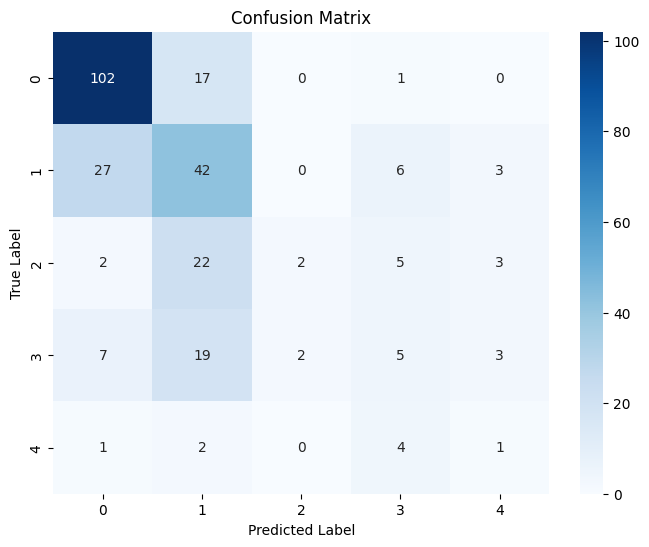

In [8]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Make predictions on the test set
y_pred = svm_model.predict(X_test_scaled)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print("\nClassification Report:\n", report)
print("\nConfusion Matrix:\n", conf_matrix)

# Visualize confusion matrix
plt.figure(figsize=(8, 6))

# Get unique class labels from the test set for xticklabels and yticklabels
class_labels = np.unique(y_test).astype(str).tolist()

sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## Task 5: Visualize Decision Boundary (using two principal components)

## Task 6: Experiment with Different Kernels

Let's experiment with different SVM kernels. The most common ones are 'linear', 'poly' (polynomial), and 'rbf' (radial basis function, which was used initially).

We will define a variable `svm_kernel` which you can easily change to try different kernels.

Linear Kernal

In [15]:
svm_kernel='linear'

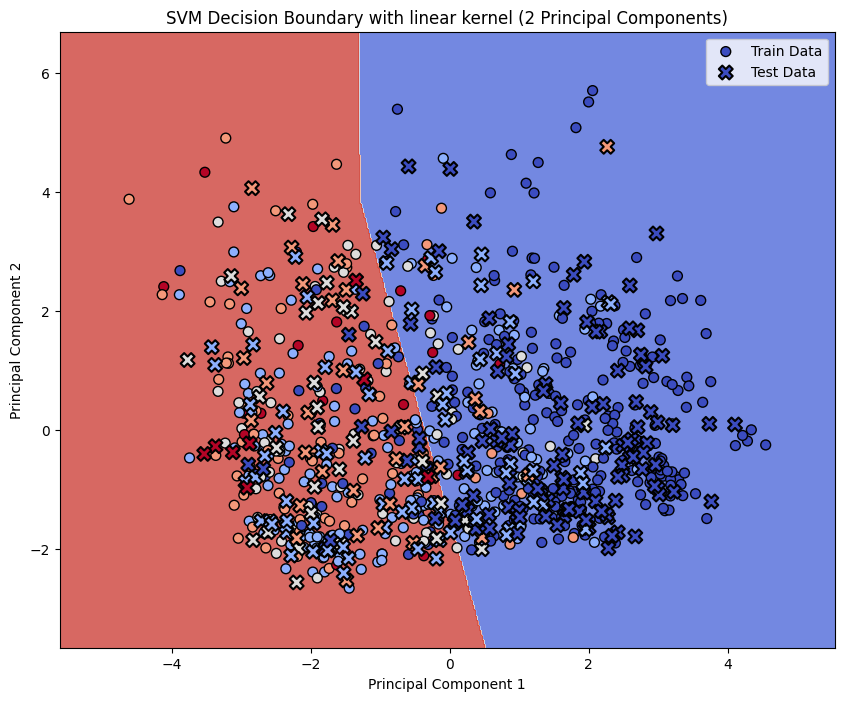

In [12]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC

# Reduce dimensionality to 2 for visualization using PCA
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Train a new SVM model on the 2D PCA data using the specified kernel
svm_model_pca = SVC(kernel=svm_kernel, random_state=42)
svm_model_pca.fit(X_train_pca, y_train)

# Create a meshgrid to plot decision boundary
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Predict on the meshgrid to get decision regions
Z = svm_model_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundary and data points
plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.coolwarm)

# Scatter plot for training data
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap=plt.cm.coolwarm, s=50, edgecolors='k', label='Train Data')

# Scatter plot for test data
plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test, cmap=plt.cm.coolwarm, s=100, marker='X', edgecolors='k', linewidth=1.5, label='Test Data')

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title(f'SVM Decision Boundary with {svm_kernel} kernel (2 Principal Components)')
plt.legend()
plt.show()

Poly Kernal

In [16]:
svm_kernel='poly'

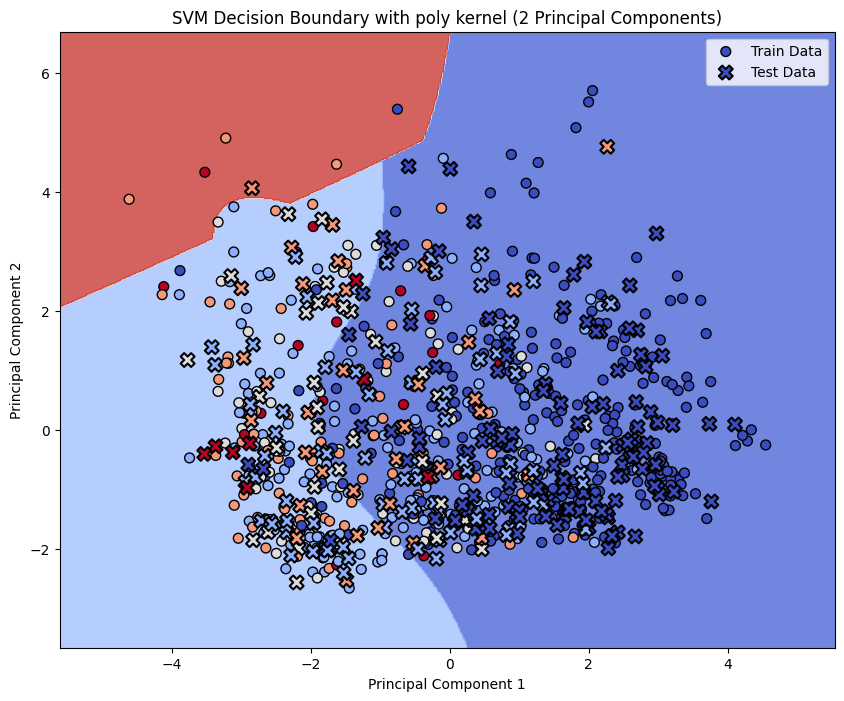

In [17]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC

# Reduce dimensionality to 2 for visualization using PCA
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Train a new SVM model on the 2D PCA data using the specified kernel
svm_model_pca = SVC(kernel=svm_kernel, random_state=42)
svm_model_pca.fit(X_train_pca, y_train)

# Create a meshgrid to plot decision boundary
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Predict on the meshgrid to get decision regions
Z = svm_model_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundary and data points
plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.coolwarm)

# Scatter plot for training data
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap=plt.cm.coolwarm, s=50, edgecolors='k', label='Train Data')

# Scatter plot for test data
plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test, cmap=plt.cm.coolwarm, s=100, marker='X', edgecolors='k', linewidth=1.5, label='Test Data')

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title(f'SVM Decision Boundary with {svm_kernel} kernel (2 Principal Components)')
plt.legend()
plt.show()

## RBF Kernel

In [18]:
svm_kernel='rbf'

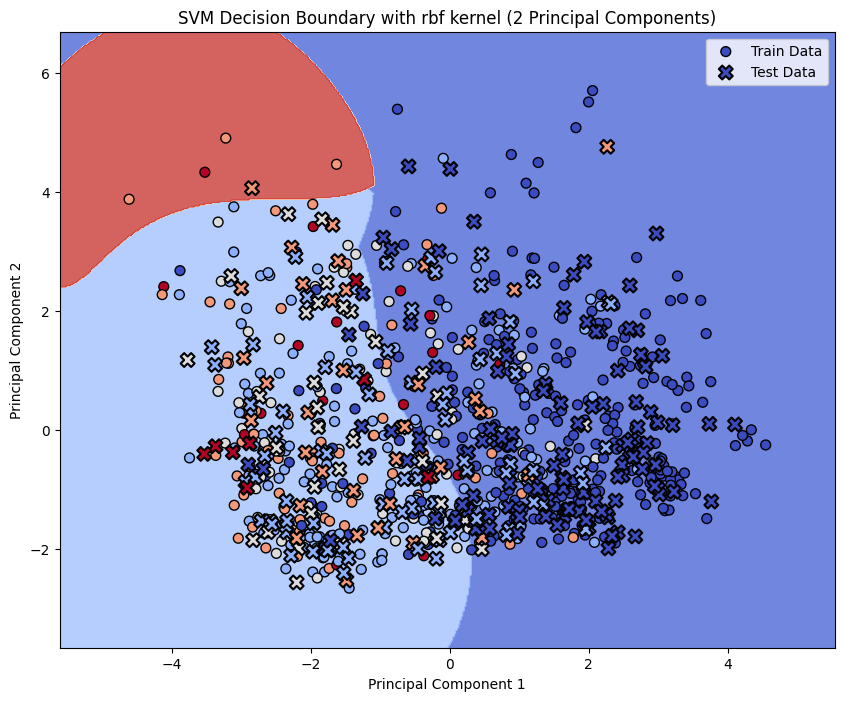

In [19]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC

# Reduce dimensionality to 2 for visualization using PCA
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Train a new SVM model on the 2D PCA data using the specified kernel
svm_model_pca = SVC(kernel=svm_kernel, random_state=42)
svm_model_pca.fit(X_train_pca, y_train)

# Create a meshgrid to plot decision boundary
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Predict on the meshgrid to get decision regions
Z = svm_model_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundary and data points
plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.coolwarm)

# Scatter plot for training data
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap=plt.cm.coolwarm, s=50, edgecolors='k', label='Train Data')

# Scatter plot for test data
plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test, cmap=plt.cm.coolwarm, s=100, marker='X', edgecolors='k', linewidth=1.5, label='Test Data')

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title(f'SVM Decision Boundary with {svm_kernel} kernel (2 Principal Components)')
plt.legend()
plt.show()

## Sigmoid Kernel

In [20]:
svm_kernel='sigmoid'

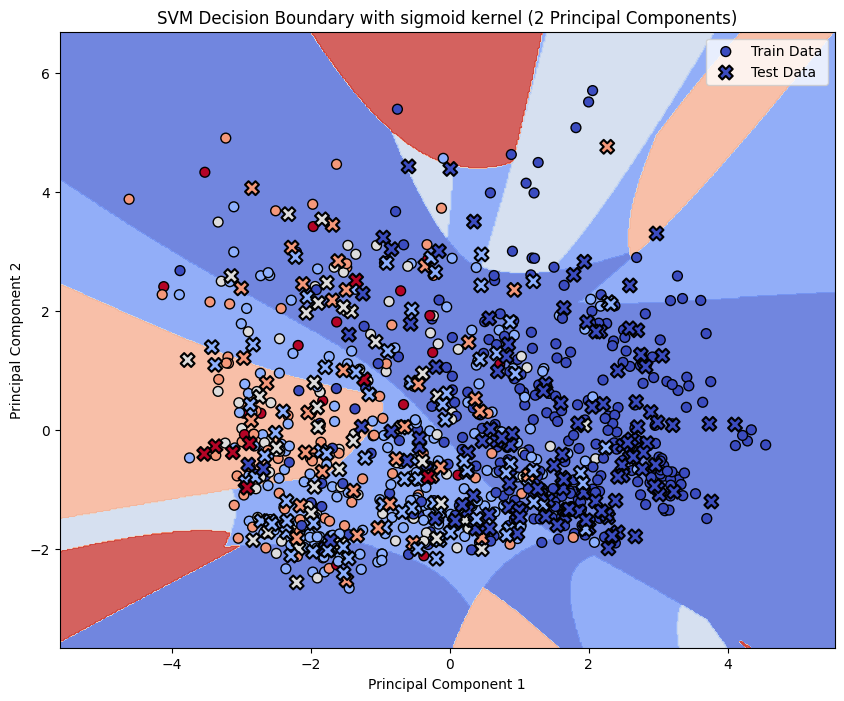

In [21]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC

# Reduce dimensionality to 2 for visualization using PCA
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Train a new SVM model on the 2D PCA data using the specified kernel
svm_model_pca = SVC(kernel=svm_kernel, random_state=42)
svm_model_pca.fit(X_train_pca, y_train)

# Create a meshgrid to plot decision boundary
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Predict on the meshgrid to get decision regions
Z = svm_model_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundary and data points
plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.coolwarm)

# Scatter plot for training data
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap=plt.cm.coolwarm, s=50, edgecolors='k', label='Train Data')

# Scatter plot for test data
plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test, cmap=plt.cm.coolwarm, s=100, marker='X', edgecolors='k', linewidth=1.5, label='Test Data')

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title(f'SVM Decision Boundary with {svm_kernel} kernel (2 Principal Components)')
plt.legend()
plt.show()

## Task 7: Compare Accuracy Scores of Different Kernels

In [22]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import pandas as pd

kernels = ['linear', 'poly', 'rbf', 'sigmoid']
accuracy_scores = {}

print("Comparing SVM Kernel Accuracies:\n")

for kernel in kernels:
    print(f"Training SVM with {kernel} kernel...")
    # Initialize and train an SVM classifier for the current kernel
    svm_model_comparison = SVC(kernel=kernel, random_state=42)
    svm_model_comparison.fit(X_train_scaled, y_train)

    # Make predictions on the test set
    y_pred_comparison = svm_model_comparison.predict(X_test_scaled)

    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred_comparison)
    accuracy_scores[kernel] = accuracy
    print(f"  Accuracy for {kernel} kernel: {accuracy:.4f}\n")

# Display all accuracy scores in a clear format
print("\n--- Summary of SVM Kernel Accuracies ---")
for kernel, accuracy in accuracy_scores.items():
    print(f"Kernel '{kernel}': {accuracy:.4f}")

# Optionally, display as a DataFrame for better readability
accuracy_df = pd.DataFrame(accuracy_scores.items(), columns=['Kernel', 'Accuracy'])
display(accuracy_df.sort_values(by='Accuracy', ascending=False))

Comparing SVM Kernel Accuracies:

Training SVM with linear kernel...
  Accuracy for linear kernel: 0.5507

Training SVM with poly kernel...
  Accuracy for poly kernel: 0.5725

Training SVM with rbf kernel...
  Accuracy for rbf kernel: 0.5507

Training SVM with sigmoid kernel...
  Accuracy for sigmoid kernel: 0.5362


--- Summary of SVM Kernel Accuracies ---
Kernel 'linear': 0.5507
Kernel 'poly': 0.5725
Kernel 'rbf': 0.5507
Kernel 'sigmoid': 0.5362


,Kernel,Accuracy
1,poly,0.572464
0,linear,0.550725
2,rbf,0.550725
3,sigmoid,0.536232


Conclusion:
 In this lab, we successfully implemented and explored Support Vector Machine (SVM) models for classification. We started by loading and preprocessing the heart disease dataset, which involved handling missing values, encoding categorical features, and scaling numerical features. After preparing the data, we split it into training and testing sets.

We then trained an SVM classifier and evaluated its performance using metrics such as accuracy, classification report, and a confusion matrix. A key part of this lab was visualizing the decision boundaries of the SVM model. To achieve this, we reduced the dimensionality of our data to two principal components using PCA, allowing for clear 2D visualizations.

Finally, we experimented with different SVM kernels, specifically 'linear', 'poly' (polynomial), 'rbf' (Radial Basis Function), and 'sigmoid'. For each kernel, we trained a new SVM model on the PCA-transformed data and visualized how each kernel creates distinct decision boundaries. This exercise provided valuable insight into how different kernels can capture varying complexities in the data and affect model separation.